Let’s see how the token ID to embedding vector conversion
works with a hands-on example.

Suppose we have the
following four input tokens with IDs 2, 3, 5, and 1

In [1]:
import torch
input_ids = torch.tensor([2,3,5,1])

For the sake of simplicity, suppose we have a small
vocabulary of only 6 words (instead of the 50,257 words in
the BPE tokenizer vocabulary), and we want to create
embeddings of size 3 (in GPT-3, the embedding size is
12,288 dimensions)

In [4]:
vocab_size = 6
output_dim = 3

Using the vocab_size and output_dim, we can instantiate an
embedding layer in PyTorch, setting the random seed to 123
for reproducibility purposes

In [5]:
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight) #prints the embedding layer’s underlying weight matrix:

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


The weight matrix of the embedding layer contains small,
random values. These values are optimized during LLM
training as part of the LLM optimization itself.

the weight matrix has six rows and three
columns. There is one row for each of the six possible tokens
in the vocabulary, and there is one column for each of the
three embedding dimensions.

In [6]:
# Applying it to a token ID to obtain the embedding vector
print(embedding_layer(torch.tensor([3])))   #this will provide the vector embedding mapped with the token '3' in the weight matrix

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


If we compare the embedding vector for token ID 3 to the
previous embedding matrix, we see that it is identical to the
fourth row (Python starts with a zero index, so it’s the row
corresponding to index 3). In other words, the embedding
layer is essentially a lookup operation that retrieves rows
from the embedding layer’s weight matrix via a token ID.

In [7]:
print(embedding_layer(input_ids))  #input_ids = torch.tensor([2,3,5,1])
#we can apply the embedding layer on the whole tensor and it will fine

#Each row in this output matrix is obtained via a lookup operation from the embedding weight matrix

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


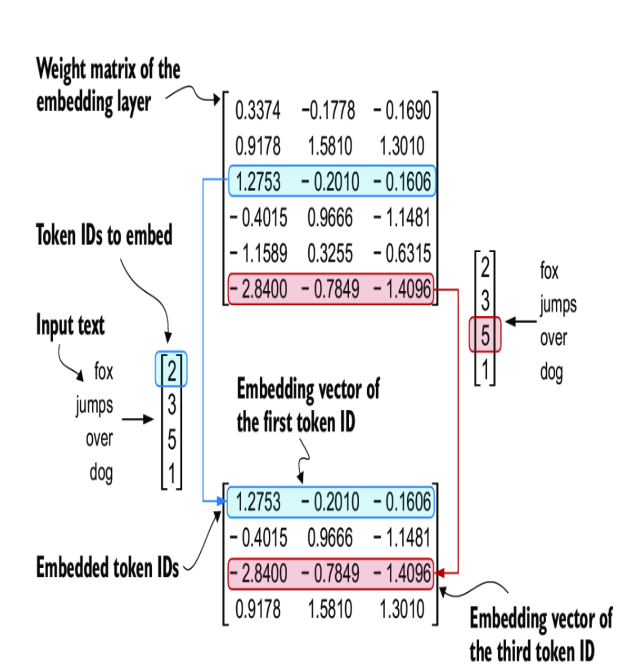

## Positional Encoding (Encoding word positions)

In principle, token embeddings are a suitable input for an
LLM. However, a minor shortcoming of LLMs is that their
self-attention mechanism doesn’t have a
notion of position or order for the tokens within a sequence. <br>

The way the previously introduced embedding layer works is
that the same token ID always gets mapped to the same
vector representation, regardless of where the token ID is
positioned in the input sequence

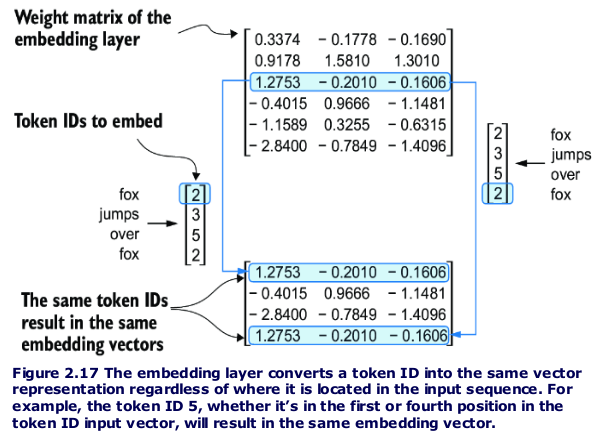

In principle, the deterministic, position-independent
embedding of the token ID is good for reproducibilitypurposes. However, since the self-attention mechanism of
LLMs itself is also position-agnostic, it is helpful to inject
additional position information into the LLM. <br>

To achieve this, we can use two broad categories of position-
aware embeddings:<br>
1. Relative positional embeddings and
2. Absolute positional embeddings. <br>
<br>
**Absolute positional**
embeddings are directly associated with specific positions in
a sequence. For each position in the input sequence, a
unique embedding is added to the token’s embedding to
convey its exact location <br>
For instance, the first token will
have a specific positional embedding, the second token
another distinct embedding, and so on.. <br>
As shown in the figure<br>
<br>
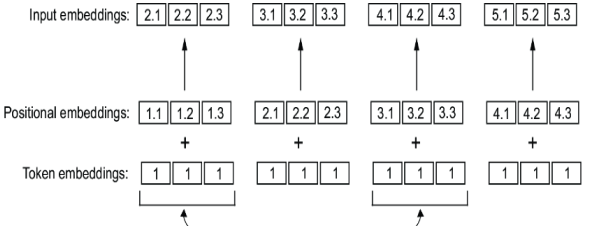 <br>
<br>
Instead of focusing on the absolute position of a token, the
emphasis of relative positional embeddings is on the relative
position or distance between tokens. This means the model
learns the relationships in terms of “how far apart” ratherthan “at which exact position.”<br>
<br>
The advantage here is that
the model can generalize better to sequences of varying
lengths, even if it hasn’t seen such lengths during training.<br>

**OpenAI’s GPT models use absolute positional embeddings
that are optimized during the training process rather than
being fixed or predefined like the positional encodings in the
original transformer model (sin, cos formulas).**
**This optimization process is part
of the model training itself.**

#### Now lets consider a vocab size of 50,257 as we are using the tiktoken and the embeddign dimensions as 256 (instead of 12,288 used in GPT-3)

In [8]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [9]:
token_embedding_layer.weight

Parameter containing:
tensor([[-2.1338,  1.0524, -0.3885,  ...,  0.2461,  1.2119,  0.3171],
        [ 1.2277, -0.4297, -2.2121,  ..., -0.1640, -0.3348, -0.0221],
        [ 1.3382,  0.2706,  0.5071,  ...,  0.0175, -2.1517,  0.3924],
        ...,
        [-1.4889, -1.2456,  1.8034,  ..., -0.6392, -1.4939,  0.3614],
        [-1.0703,  0.2795, -0.2637,  ..., -0.2810, -1.4755, -0.1183],
        [-0.0071,  0.4982, -0.3319,  ...,  0.4970,  0.9365, -0.2091]],
       requires_grad=True)

In [10]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

from torch.utils.data import Dataset, DataLoader
import tiktoken


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length] #context length chunk
            target_chunk = token_ids[i + 1: i + max_length + 1]  #shifted by 1
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):  #provided the index, it provides the input_id and target_id present on that index 
        return self.input_ids[idx], self.target_ids[idx]
    
def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [11]:
max_length = 4
dataloader = create_dataloader_v1(
raw_text, batch_size=8, max_length=max_length,
stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:\n torch.Size([8, 4])


As we can see, the token ID tensor is 8 × 4 dimensional,
meaning that the data batch consists of eight text samples
with four tokens each. <br>

Let’s now use the embedding layer to embed these token IDs
into 256-dimensional vectors

In [12]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape) 

torch.Size([8, 4, 256])


The 8 × 4 × 256–dimensional tensor output shows that each
token ID is now embedded as a 256-dimensional vector. <br>

Here 8 shows the number of rows, i.e the number of forward propagation(prediction) after which the weights will be optimized <br>
4 shows the number of columns i.e the number of tokens which are used for prediction, this is also the context lenght with this much max number of tokens as input the model can predict output. <br>
256 is the dimension of the the embedding each of the tokem is mapped to an embedding of 256 dimension in the look up table 

For a GPT model’s absolute embedding approach, we just
need to create another embedding layer that has the same
embedding dimension as the token_embedding_ layer. <br>
<br>

As shown in the image, as for every token there is an individual unique value to be added for encoding the position of the token. The dimension of the embedding and positional embeddings should be the same. i.e 256 in this case 
<br>
<br>
Moreover as there are unique value for each token, there would be look up table for each of the token<br>
The look up table is optimized also when we are optimizing the LLM along with the token encoding weight matrix. 



In [15]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings)
print(pos_embeddings.shape)

tensor([[-0.8194,  0.5543, -0.8290,  ...,  0.1325,  0.2115,  0.3610],
        [ 0.4193, -0.9461, -0.3407,  ...,  0.7930,  1.7009,  0.5663],
        [-0.2362, -1.7187, -1.0489,  ...,  1.1218,  0.2796,  0.9912],
        [-0.9549,  0.4699,  0.2580,  ..., -1.3689,  1.6505,  1.3488]],
       grad_fn=<EmbeddingBackward0>)
torch.Size([4, 256])


As we can see, the positional embedding tensor consists of
four 256-dimensional vectors. We can now add these
directly to the token embeddings, where PyTorch will add
the 4 × 256–dimensional pos_embeddings tensor to each 4 ×
256–dimensional token embedding tensor in each of the
eight batches

In [16]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])
